# 🌦️ XGBoost Weather Forecasting & Temperature Prediction Model
### **Dataset**: `bengaluru_preprocessed.csv` (2001 – 2026)
### **Target Variable**: Hourly 2-Meter Air Temperature (`temperature_2m`)

---
### 📌 Key Features in this Notebook:
1. **Time-Series Aware Preprocessing**: Chronological splitting to prevent data leakage.
2. **Cyclical & Inertial Feature Engineering**: Sine/Cosine encodings, 1h/24h lags, 24h rolling aggregations, and categorical one-hot encoding.
3. **Advanced XGBoost Regressor**: Gradient boosting with histogram tree method, regularization, and early stopping.
4. **Rich Multi-Panel Visualization Suite**:
   - 📊 Learning curves & 300-hour zoom trace
   - 🎯 Regression scatter density with $\pm 1^\circ	ext{C}$ / $\pm 2^\circ	ext{C}$ error margins
   - ⏱️ Diurnal (24-Hour) temperature cycle profile
   - 🌡️ Seasonal & hourly MAE heatmap / error distributions
   - 📈 Cumulative Accuracy Curve (CDF)
5. **Interactive User Input & Real-Time Prediction Simulator**:
   - 🎮 Custom input dictionary sandbox (modify parameters & get instant temperature forecast)
   - ⚡ Pre-configured weather scenario presets (*Summer Afternoon*, *Monsoon Evening*, *Winter Morning*)
   - 🎛️ Interactive Sliders GUI (`ipywidgets`) for live parameter tuning!

## 📦 Step 1: Import Libraries & Configure Aesthetics

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score
)

# Optional interactive widgets for notebook UI
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print(f"XGBoost Version : {xgb.__version__}")
print(f"Pandas Version  : {pd.__version__}")
print(f"Interactive Widgets Available: {HAS_WIDGETS}")

XGBoost Version : 3.1.3
Pandas Version  : 2.3.3
Interactive Widgets Available: False


## 📂 Step 2: Load the Preprocessed Dataset (`bengaluru_preprocessed.csv`)

In [2]:
df_raw = pd.read_csv('bengaluru_preprocessed.csv')
print(f"Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 225,144 rows, 39 columns


,time,temperature_2m,relative_humidity_2m,apparent_temperature,dew_point_2m,precipitation,rain,weather_code,pressure_msl,surface_pressure,...,year,month,day,hour,day_of_week,day_name,is_weekend,quarter,season,log_precipitation
0,2001-01-01 00:00:00,18.7,96,20.4,18.0,0.0,0.0,3,1012.1,910.0,...,2001,1,1,0,0,Monday,0,1,Winter,0.0
1,2001-01-01 01:00:00,18.7,95,20.5,17.9,0.0,0.0,3,1012.6,910.4,...,2001,1,1,1,0,Monday,0,1,Winter,0.0
2,2001-01-01 02:00:00,19.0,93,20.6,17.8,0.0,0.0,3,1013.3,911.2,...,2001,1,1,2,0,Monday,0,1,Winter,0.0
3,2001-01-01 03:00:00,20.5,82,21.8,17.4,0.0,0.0,3,1014.2,912.5,...,2001,1,1,3,0,Monday,0,1,Winter,0.0
4,2001-01-01 04:00:00,22.4,71,23.7,16.9,0.0,0.0,3,1014.2,913.1,...,2001,1,1,4,0,Monday,0,1,Winter,0.0


## ⚙️ Step 3: Advanced Feature Engineering
- **Cyclical Transformations**: Sin/Cos encoding for `hour`, `month`, and `day_of_year`
- **Lag Features**: 1-hour and 24-hour historical lags for temperature, humidity, pressure, and wind
- **Rolling Window Statistics**: 24-hour rolling mean and standard deviation
- **Categorical One-Hot Encoding**: `season` and `day_name`

In [3]:
df = df_raw.copy()

# 1. Datetime formatting and chronological ordering
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# 2. Cyclical Temporal Encoding
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
df['day_of_year'] = df['time'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)

# 3. Lag Features for thermal inertia
lag_features = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
for col in lag_features:
    if col in df.columns:
        df[f'{col}_lag_1h'] = df[col].shift(1)
        df[f'{col}_lag_24h'] = df[col].shift(24)

# 4. Rolling Window Statistics
df['temp_rolling_mean_24h'] = df['temperature_2m'].shift(1).rolling(window=24).mean()
df['temp_rolling_std_24h'] = df['temperature_2m'].shift(1).rolling(window=24).std()
df['humidity_rolling_mean_24h'] = df['relative_humidity_2m'].shift(1).rolling(window=24).mean()

# Drop warm-up NaN rows caused by 24h lag/rolling
df = df.dropna().reset_index(drop=True)

# 5. One-Hot Encoding for remaining categorical columns
cat_cols = [c for c in ['season', 'day_name'] if c in df.columns]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)

print(f"Final Engineered Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df[['time', 'temperature_2m', 'hour_sin', 'hour_cos', 'temperature_2m_lag_1h', 'temp_rolling_mean_24h']].head()

Final Engineered Dataset Shape: 225,120 rows, 64 columns


,time,temperature_2m,hour_sin,hour_cos,temperature_2m_lag_1h,temp_rolling_mean_24h
0,2001-01-02 00:00:00,18.7,0.000000,1.000000,18.4,21.400000
1,2001-01-02 01:00:00,19.0,0.258819,0.965926,18.7,21.400000
2,2001-01-02 02:00:00,19.3,0.500000,0.866025,19.0,21.412500
3,2001-01-02 03:00:00,20.4,0.707107,0.707107,19.3,21.425000
4,2001-01-02 04:00:00,21.7,0.866025,0.500000,20.4,21.420833


## ✂️ Step 4: Time-Series Chronological Train-Val-Test Split
- **Training Set (80%)**: 2001 to mid-2021
- **Validation Set (10%)**: mid-2021 to early-2024 (For Early Stopping)
- **Test Set (10%)**: early-2024 to late-2026 (Unseen Test Evaluation)

In [4]:
target_col = 'temperature_2m'
drop_cols = ['time', target_col, 'apparent_temperature', 'dew_point_2m', 'soil_temperature_0_to_7cm']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]
timestamps = df['time']

n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]
test_timestamps = timestamps.iloc[val_end:].reset_index(drop=True)

# Store feature medians/defaults for user inference fallback
feature_defaults = X_train.median().to_dict()

print(f"Training Set   : {len(X_train):,} samples ({timestamps.iloc[0].date()} to {timestamps.iloc[train_end - 1].date()})")
print(f"Validation Set : {len(X_val):,} samples ({timestamps.iloc[train_end].date()} to {timestamps.iloc[val_end - 1].date()})")
print(f"Test Set       : {len(X_test):,} samples ({timestamps.iloc[val_end].date()} to {timestamps.iloc[-1].date()})")
print(f"Total Features : {X.shape[1]}")

Training Set   : 180,096 samples (2001-01-02 to 2021-07-19)
Validation Set : 22,512 samples (2021-07-20 to 2024-02-12)
Test Set       : 22,512 samples (2024-02-13 to 2026-09-07)
Total Features : 59


## 🚀 Step 5: XGBoost Model Architecture & Training with Early Stopping

In [5]:
params = {
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'gamma': 0.1,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'eval_metric': 'rmse',
    'early_stopping_rounds': 50
}

model = xgb.XGBRegressor(**params)

print("Training XGBoost Regressor with early stopping...")
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\nOptimal Boosting Iterations: {model.best_iteration}")
print(f"Best Validation RMSE: {model.best_score:.4f} °C")

Training XGBoost Regressor with early stopping...
[0]	validation_0-rmse:4.09916	validation_1-rmse:3.86162
[100]	validation_0-rmse:0.39222	validation_1-rmse:0.45130
[200]	validation_0-rmse:0.26682	validation_1-rmse:0.35017
[300]	validation_0-rmse:0.24165	validation_1-rmse:0.32559
[400]	validation_0-rmse:0.22264	validation_1-rmse:0.30591
[500]	validation_0-rmse:0.20914	validation_1-rmse:0.29270
[600]	validation_0-rmse:0.19889	validation_1-rmse:0.28317
[700]	validation_0-rmse:0.19097	validation_1-rmse:0.27628
[800]	validation_0-rmse:0.18423	validation_1-rmse:0.27053
[900]	validation_0-rmse:0.17833	validation_1-rmse:0.26533
[999]	validation_0-rmse:0.17351	validation_1-rmse:0.26145

Optimal Boosting Iterations: 999
Best Validation RMSE: 0.2615 °C


## 📊 Step 6: Multi-Metric Performance Evaluation

In [6]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

def evaluate_performance(y_true, y_pred, split_label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    evs = explained_variance_score(y_true, y_pred)
    return {
        'Dataset Split': split_label,
        'RMSE (°C)': rmse,
        'MAE (°C)': mae,
        'MSE (°C²)': mse,
        'R² Score': r2,
        'MAPE (%)': mape,
        'Explained Variance': evs
    }

metrics_train = evaluate_performance(y_train, y_pred_train, 'Train Set')
metrics_test = evaluate_performance(y_test, y_pred_test, 'Test Set (Unseen)')

metrics_df = pd.DataFrame([metrics_train, metrics_test]).set_index('Dataset Split')
display(metrics_df.style.format('{:.4f}').background_gradient(cmap='Blues'))

,RMSE (°C),MAE (°C),MSE (°C²),R² Score,MAPE (%),Explained Variance
Dataset Split,,,,,,
Train Set,0.1735,0.1303,0.0301,0.9983,0.5851,0.9983
Test Set (Unseen),0.3265,0.2252,0.1066,0.9941,0.9379,0.9941


## 📈 Step 7: Comprehensive Multi-Angle Visualization Suite
Explore the model's predictive precision through five specialized visual diagnostics:
1. **Core Diagnostic Dashboard**: Training curves, 300-hour zoom trace, error residual distribution, and top 15 feature importances.
2. **Regression Scatter & Accuracy Bands**: Actual vs. Predicted scatter with ideal 45° reference line and $\pm 1^\circ\text{C}$ error margins.
3. **Diurnal Temperature Cycle**: 24-hour average actual vs. predicted curves showing morning lows and afternoon highs.
4. **Seasonal & Hourly Error Breakdown**: Heatmap of Mean Absolute Error across months and hours.
5. **Cumulative Error Curve (CDF)**: Percentage of test forecasts achieving fine precision thresholds.

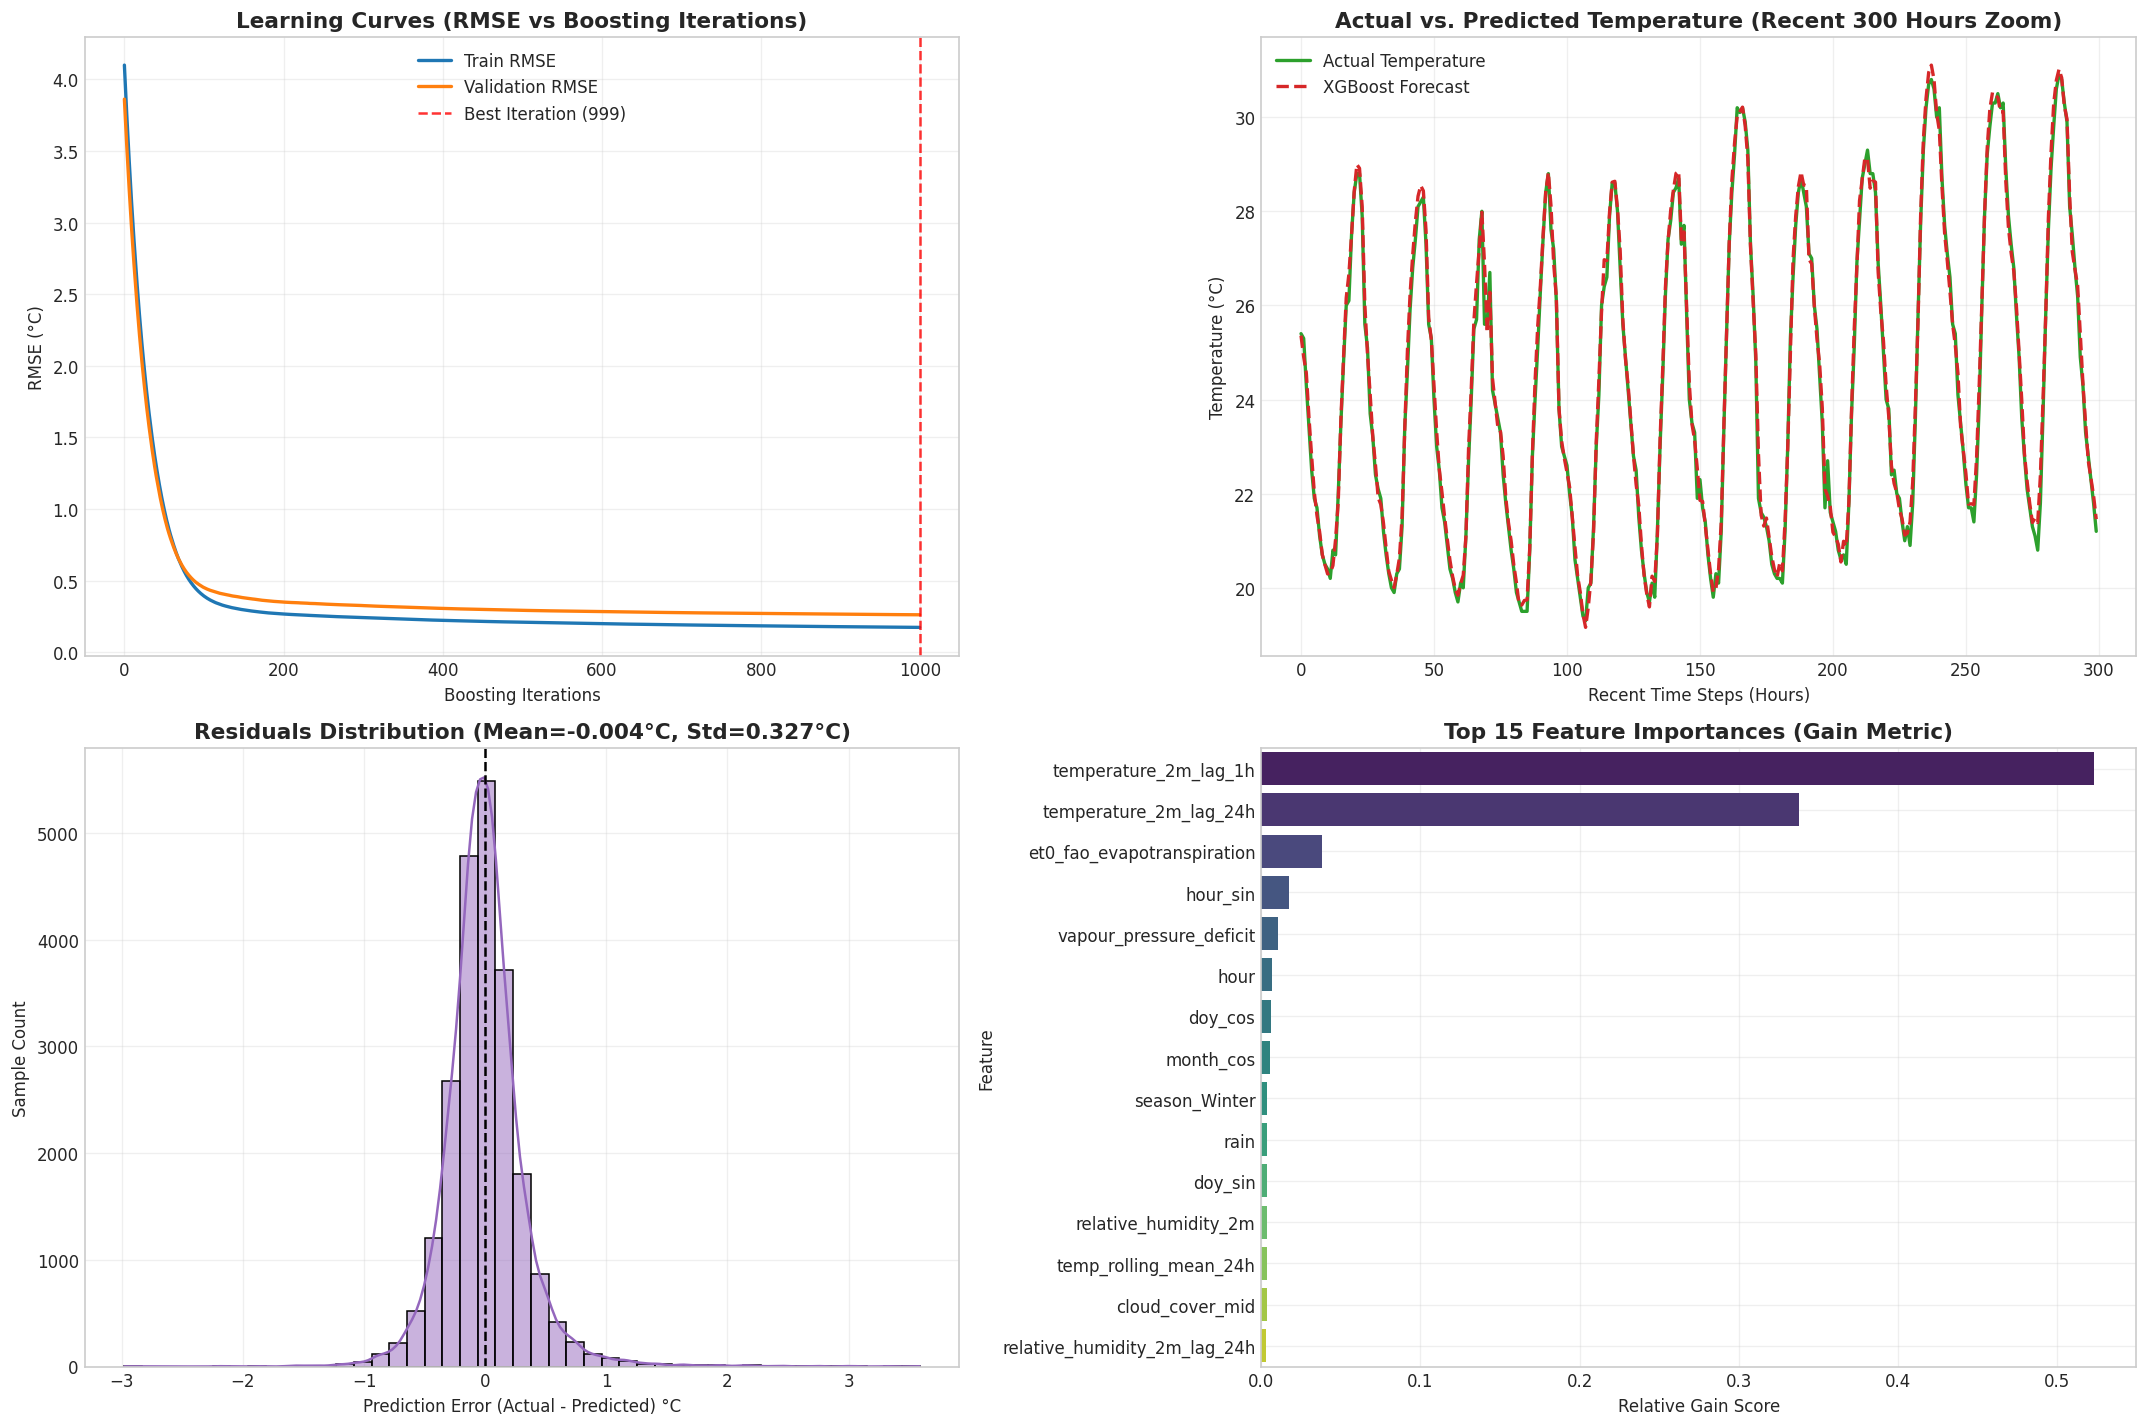

In [7]:
# -------------------------------------------------------------
# 1. CORE 4-PANEL DIAGNOSTIC DASHBOARD
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# (A) Learning Curves
evals_result = model.evals_result()
axes[0, 0].plot(evals_result['validation_0']['rmse'], label='Train RMSE', color='#1f77b4', lw=2)
axes[0, 0].plot(evals_result['validation_1']['rmse'], label='Validation RMSE', color='#ff7f0e', lw=2)
axes[0, 0].axvline(model.best_iteration, color='red', linestyle='--', alpha=0.8, label=f'Best Iteration ({model.best_iteration})')
axes[0, 0].set_title('Learning Curves (RMSE vs Boosting Iterations)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Boosting Iterations')
axes[0, 0].set_ylabel('RMSE (°C)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# (B) Actual vs Predicted (Recent 300 Hours Zoom)
zoom = min(300, len(y_test))
axes[0, 1].plot(range(zoom), y_test.iloc[-zoom:].values, label='Actual Temperature', color='#2ca02c', lw=2)
axes[0, 1].plot(range(zoom), y_pred_test[-zoom:], label='XGBoost Forecast', color='#d62728', linestyle='--', lw=2)
axes[0, 1].set_title(f'Actual vs. Predicted Temperature (Recent {zoom} Hours Zoom)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Recent Time Steps (Hours)')
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (C) Residual Distribution
residuals = y_test.values - y_pred_test
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='#9467bd', bins=45)
axes[1, 0].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1, 0].set_title(f'Residuals Distribution (Mean={residuals.mean():.3f}°C, Std={residuals.std():.3f}°C)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Prediction Error (Actual - Predicted) °C')
axes[1, 0].set_ylabel('Sample Count')
axes[1, 0].grid(True, alpha=0.3)

# (D) Top 15 Feature Importances (Gain)
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False).head(15)
sns.barplot(x='Importance', y='Feature', data=imp_df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 15 Feature Importances (Gain Metric)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Relative Gain Score')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

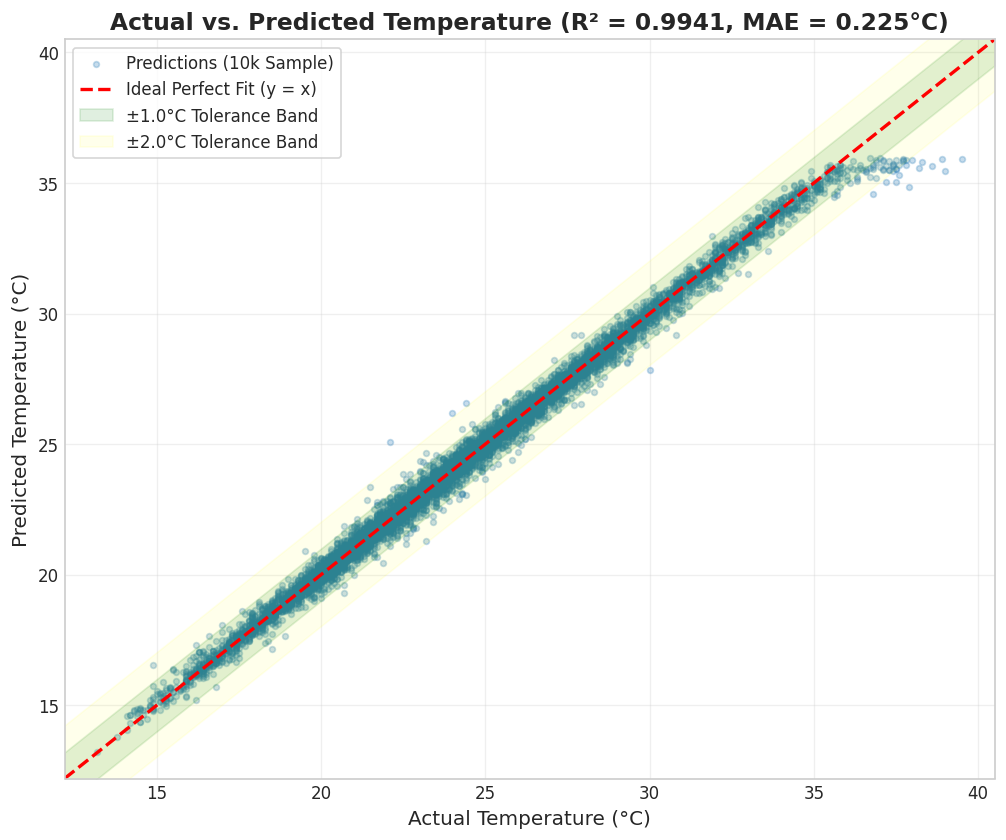

In [8]:
# -------------------------------------------------------------
# 2. ACTUAL VS PREDICTED SCATTER & DENSITY WITH CONFIDENCE BANDS
# -------------------------------------------------------------
plt.figure(figsize=(10, 8))
sample_idx = np.random.choice(len(y_test), size=min(10000, len(y_test)), replace=False)
plt.scatter(y_test.iloc[sample_idx], y_pred_test[sample_idx], alpha=0.25, color='#1f77b4', s=12, label='Predictions (10k Sample)')

min_val = min(y_test.min(), y_pred_test.min()) - 1
max_val = max(y_test.max(), y_pred_test.max()) + 1

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Perfect Fit (y = x)')
plt.fill_between([min_val, max_val], [min_val - 1, max_val - 1], [min_val + 1, max_val + 1], color='green', alpha=0.12, label='±1.0°C Tolerance Band')
plt.fill_between([min_val, max_val], [min_val - 2, max_val - 2], [min_val + 2, max_val + 2], color='yellow', alpha=0.08, label='±2.0°C Tolerance Band')

plt.title(f'Actual vs. Predicted Temperature (R² = {r2_score(y_test, y_pred_test):.4f}, MAE = {mean_absolute_error(y_test, y_pred_test):.3f}°C)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.3)
plt.show()

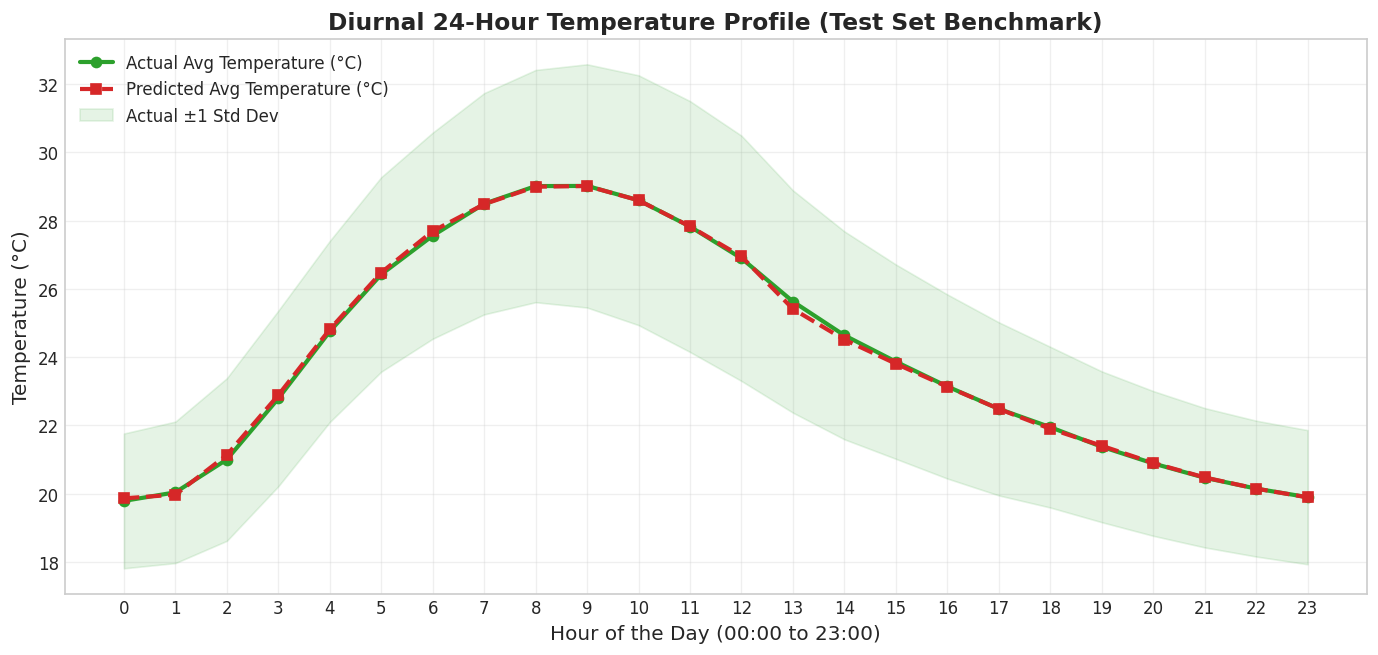

In [9]:
# -------------------------------------------------------------
# 3. DIURNAL (24-HOUR) TEMPERATURE CYCLE PROFILE
# -------------------------------------------------------------
eval_df = pd.DataFrame({
    'hour': X_test['hour'].values,
    'month': X_test['month'].values,
    'actual': y_test.values,
    'predicted': y_pred_test,
    'error': np.abs(y_test.values - y_pred_test)
})

hourly_profile = eval_df.groupby('hour')[['actual', 'predicted']].mean()
hourly_std = eval_df.groupby('hour')[['actual', 'predicted']].std()

plt.figure(figsize=(14, 6))
plt.plot(hourly_profile.index, hourly_profile['actual'], 'o-', color='#2ca02c', lw=2.5, label='Actual Avg Temperature (°C)')
plt.plot(hourly_profile.index, hourly_profile['predicted'], 's--', color='#d62728', lw=2.5, label='Predicted Avg Temperature (°C)')
plt.fill_between(hourly_profile.index, hourly_profile['actual'] - hourly_std['actual'], hourly_profile['actual'] + hourly_std['actual'], color='#2ca02c', alpha=0.12, label='Actual ±1 Std Dev')

plt.title('Diurnal 24-Hour Temperature Profile (Test Set Benchmark)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (00:00 to 23:00)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

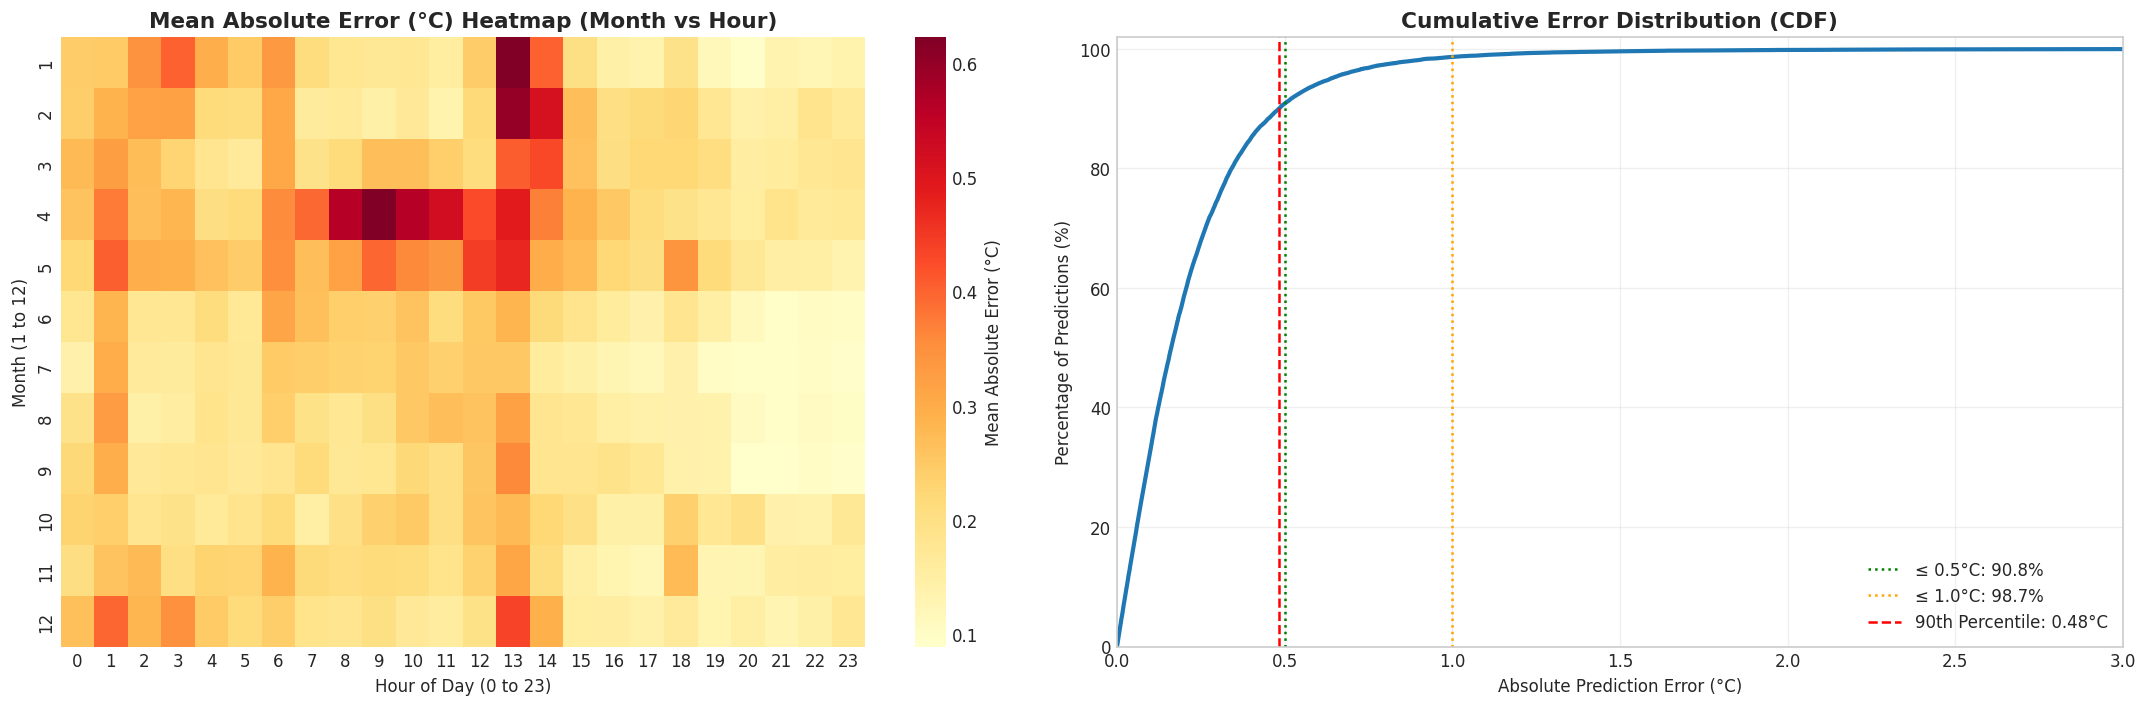

In [10]:
# -------------------------------------------------------------
# 4. SEASONAL & HOURLY ERROR HEATMAP & ACCURACY CDF
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (A) Error Heatmap across Hours & Months
error_pivot = eval_df.pivot_table(index='month', columns='hour', values='error', aggfunc='mean')
sns.heatmap(error_pivot, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Mean Absolute Error (°C)'}, annot=False)
axes[0].set_title('Mean Absolute Error (°C) Heatmap (Month vs Hour)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0 to 23)')
axes[0].set_ylabel('Month (1 to 12)')

# (B) Cumulative Accuracy Curve (CDF)
sorted_errors = np.sort(eval_df['error'].values)
cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100

axes[1].plot(sorted_errors, cdf, color='#1f77b4', lw=2.5)
p50 = np.percentile(sorted_errors, 50)
p90 = np.percentile(sorted_errors, 90)
p99 = np.percentile(sorted_errors, 99)

axes[1].axvline(0.5, color='green', linestyle=':', label=f'≤ 0.5°C: {(sorted_errors <= 0.5).mean()*100:.1f}%')
axes[1].axvline(1.0, color='orange', linestyle=':', label=f'≤ 1.0°C: {(sorted_errors <= 1.0).mean()*100:.1f}%')
axes[1].axvline(p90, color='red', linestyle='--', label=f'90th Percentile: {p90:.2f}°C')

axes[1].set_title('Cumulative Error Distribution (CDF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Absolute Prediction Error (°C)')
axes[1].set_ylabel('Percentage of Predictions (%)')
axes[1].set_xlim(0, 3.0)
axes[1].set_ylim(0, 102)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 💾 Step 8: Save Model Artifacts

In [11]:
joblib.dump(model, 'xgboost_weather_model.joblib')
model.save_model('xgboost_weather_model.json')

metadata = {
    'model_name': 'XGBoost Regressor (Weather Forecast)',
    'target': target_col,
    'features': feature_cols,
    'test_metrics': metrics_df.loc['Test Set (Unseen)'].to_dict()
}

with open('xgboost_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Artifacts successfully saved: xgboost_weather_model.joblib, xgboost_weather_model.json, xgboost_model_metadata.json")

Artifacts successfully saved: xgboost_weather_model.joblib, xgboost_weather_model.json, xgboost_model_metadata.json


## 🔮 Step 9: User Input Prediction Engine
Define an intuitive custom prediction function `predict_custom_weather(...)` that:
- Accepts human-readable meteorological values (temperature 1h ago, humidity, wind, pressure, cloud cover, time of day, season, etc.)
- Automatically computes cyclical trigonometric features (`hour_sin/cos`, `month_sin/cos`, `doy_sin/cos`)
- Intelligently encodes categorical variables and infers rolling window averages
- Formats the predicted result with a **Thermal Comfort & Weather Classification Dashboard**!

In [12]:
def predict_custom_weather(user_input_dict, trained_model=model, features=feature_cols, defaults=feature_defaults):
    """
    Takes a dictionary of user-specified weather and temporal inputs,
    computes derived/cyclical features, fills defaults for omitted sensors,
    and returns the predicted 2-meter air temperature with formatted diagnostics.
    """
    # Start with default dataset medians
    input_row = defaults.copy()
    
    # 1. Extract core parameters
    hour = user_input_dict.get('hour', 12)
    month = user_input_dict.get('month', 6)
    day = user_input_dict.get('day', 15)
    year = user_input_dict.get('year', 2026)
    day_name = user_input_dict.get('day_name', 'Monday')
    season = user_input_dict.get('season', 'Summer')
    
    # 2. Direct sensor readings from user
    for key in ['relative_humidity_2m', 'surface_pressure', 'wind_speed_10m', 'cloud_cover', 
                'precipitation', 'rain', 'weather_code', 'pressure_msl', 'wind_speed_100m',
                'wind_direction_10m', 'wind_direction_100m', 'wind_gusts_10m',
                'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm',
                'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm', 'soil_moisture_100_to_255cm',
                'et0_fao_evapotranspiration', 'vapour_pressure_deficit']:
        if key in user_input_dict:
            input_row[key] = user_input_dict[key]
            
    # 3. Handle temperature lag and rolling features
    temp_lag_1h = user_input_dict.get('temperature_2m_lag_1h', user_input_dict.get('temp_1h_ago', 25.0))
    temp_lag_24h = user_input_dict.get('temperature_2m_lag_24h', user_input_dict.get('temp_yesterday', temp_lag_1h))
    temp_rolling_mean = user_input_dict.get('temp_rolling_mean_24h', temp_lag_1h)
    temp_rolling_std = user_input_dict.get('temp_rolling_std_24h', 3.0)
    
    input_row['temperature_2m_lag_1h'] = temp_lag_1h
    input_row['temperature_2m_lag_24h'] = temp_lag_24h
    input_row['temp_rolling_mean_24h'] = temp_rolling_mean
    input_row['temp_rolling_std_24h'] = temp_rolling_std
    
    # Humidity lag
    hum = input_row.get('relative_humidity_2m', 60.0)
    input_row['relative_humidity_2m_lag_1h'] = user_input_dict.get('relative_humidity_2m_lag_1h', hum)
    input_row['relative_humidity_2m_lag_24h'] = user_input_dict.get('relative_humidity_2m_lag_24h', hum)
    input_row['humidity_rolling_mean_24h'] = user_input_dict.get('humidity_rolling_mean_24h', hum)
    
    # Surface pressure lag
    pres = input_row.get('surface_pressure', 915.0)
    input_row['surface_pressure_lag_1h'] = user_input_dict.get('surface_pressure_lag_1h', pres)
    input_row['surface_pressure_lag_24h'] = user_input_dict.get('surface_pressure_lag_24h', pres)
    
    # Wind lag
    wspd = input_row.get('wind_speed_10m', 10.0)
    input_row['wind_speed_10m_lag_1h'] = user_input_dict.get('wind_speed_10m_lag_1h', wspd)
    input_row['wind_speed_10m_lag_24h'] = user_input_dict.get('wind_speed_10m_lag_24h', wspd)
    
    # 4. Temporal & Cyclical calculations
    input_row['hour'] = hour
    input_row['month'] = month
    input_row['day'] = day
    input_row['year'] = year
    input_row['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    input_row['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
    input_row['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    input_row['month_cos'] = np.cos(2 * np.pi * month / 12.0)
    
    # Day of year calculation
    approx_doy = int((month - 1) * 30.4 + day)
    input_row['day_of_year'] = approx_doy
    input_row['doy_sin'] = np.sin(2 * np.pi * approx_doy / 365.25)
    input_row['doy_cos'] = np.cos(2 * np.pi * approx_doy / 365.25)
    
    # Calendar flags
    input_row['day_of_week'] = user_input_dict.get('day_of_week', 2)
    input_row['is_weekend'] = 1.0 if day_name in ['Saturday', 'Sunday'] else 0.0
    input_row['quarter'] = int((month - 1) // 3 + 1)
    precip = input_row.get('precipitation', 0.0)
    input_row['log_precipitation'] = np.log1p(precip)
    
    # 5. One-Hot Encoding flags
    for s in ['Post_Monsoon', 'Summer', 'Winter']:
        input_row[f'season_{s}'] = 1.0 if season.lower() == s.lower() else 0.0
    for d in ['Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']:
        input_row[f'day_name_{d}'] = 1.0 if day_name.lower() == d.lower() else 0.0
        
    # Construct ordered feature DataFrame
    input_df = pd.DataFrame([input_row])[features]
    
    # Run XGBoost Prediction
    pred_temp = float(trained_model.predict(input_df)[0])
    
    # Thermal Comfort & Category
    if pred_temp < 15:
        category = "❄️ Chilly / Cold"
        badge = "Cold"
    elif pred_temp < 22:
        category = "🍃 Cool & Pleasant"
        badge = "Pleasant"
    elif pred_temp < 28:
        category = "☀️ Warm & Comfortable"
        badge = "Comfortable"
    elif pred_temp < 34:
        category = "🔥 Hot"
        badge = "Hot"
    else:
        category = "🚨 Very Hot / Heatwave"
        badge = "Extreme Heat"
        
    return {
        'predicted_temperature_c': round(pred_temp, 2),
        'predicted_temperature_f': round(pred_temp * 9/5 + 32, 2),
        'thermal_category': category,
        'badge': badge,
        'input_summary': {
            'Time': f"{hour:02d}:00",
            'Month': month,
            'Season': season,
            'Prior Temp (1h ago)': f"{temp_lag_1h:.1f} °C",
            'Humidity': f"{input_row.get('relative_humidity_2m', 60):.1f}%",
            'Surface Pressure': f"{input_row.get('surface_pressure', 915):.1f} hPa",
            'Wind Speed': f"{input_row.get('wind_speed_10m', 10):.1f} km/h",
            'Cloud Cover': f"{input_row.get('cloud_cover', 20):.1f}%",
            'Precipitation': f"{precip:.1f} mm"
        }
    }

def display_weather_prediction_card(result):
    """Displays an attractive formatted dashboard card for custom prediction results."""
    pred_c = result['predicted_temperature_c']
    pred_f = result['predicted_temperature_f']
    cat = result['thermal_category']
    summary = result['input_summary']
    
    print("=" * 60)
    print(" 🌦️  XGBOOST WEATHER FORECAST RESULT")
    print("=" * 60)
    print(f"  🌡️  PREDICTED TEMPERATURE : {pred_c:.2f} °C  ({pred_f:.2f} °F)")
    print(f"  🏷️  COMFORT CLASSIFICATION: {cat}")
    print("-" * 60)
    print("  📋 INPUT CONDITIONS:")
    for k, v in summary.items():
        print(f"     • {k:<22}: {v}")
    print("=" * 60)

## 🎮 Step 10: Interactive User Input Sandbox & Scenario Simulation
Modify the dictionary below with your own custom conditions, or run the pre-built scenarios!

In [13]:
# =============================================================================
# ✏️ YOUR CUSTOM INPUT SANDBOX - FEEL FREE TO EDIT ANY VALUES BELOW!
# =============================================================================
my_custom_weather = {
    'hour': 14,                      # Hour of day (0 to 23) -> 14 = 2:00 PM
    'month': 5,                      # Month (1 to 12) -> 5 = May
    'day': 18,                       # Day of month
    'season': 'Summer',              # 'Summer', 'Winter', 'Monsoon', 'Post_Monsoon'
    'day_name': 'Wednesday',         # 'Monday', 'Tuesday', ..., 'Sunday'
    
    # Meteorological Readings
    'temp_1h_ago': 31.5,             # Air temperature 1 hour ago (°C)
    'relative_humidity_2m': 42.0,    # Relative Humidity (0 - 100 %)
    'surface_pressure': 912.0,       # Surface Pressure (hPa) (Bengaluru ~910-925 hPa)
    'wind_speed_10m': 14.0,          # Wind Speed at 10m (km/h)
    'cloud_cover': 15.0,             # Cloud cover percentage (0 - 100 %)
    'precipitation': 0.0             # Precipitation (mm)
}

# Run the forecast
custom_result = predict_custom_weather(my_custom_weather)
display_weather_prediction_card(custom_result)

 🌦️  XGBOOST WEATHER FORECAST RESULT
  🌡️  PREDICTED TEMPERATURE : 26.25 °C  (79.25 °F)
  🏷️  COMFORT CLASSIFICATION: ☀️ Warm & Comfortable
------------------------------------------------------------
  📋 INPUT CONDITIONS:
     • Time                  : 14:00
     • Month                 : 5
     • Season                : Summer
     • Prior Temp (1h ago)   : 31.5 °C
     • Humidity              : 42.0%
     • Surface Pressure      : 912.0 hPa
     • Wind Speed            : 14.0 km/h
     • Cloud Cover           : 15.0%
     • Precipitation         : 0.0 mm


### ⚡ Pre-Configured Weather Scenarios Benchmark

In [14]:
scenarios = {
    "☀️ Summer Scorching Afternoon (May 2:00 PM)": {
        'hour': 14, 'month': 5, 'season': 'Summer', 'day_name': 'Monday',
        'temp_1h_ago': 33.2, 'relative_humidity_2m': 32.0, 'surface_pressure': 910.5,
        'wind_speed_10m': 16.0, 'cloud_cover': 10.0, 'precipitation': 0.0
    },
    "🌧️ Monsoon Rainy Evening (August 6:00 PM)": {
        'hour': 18, 'month': 8, 'season': 'Monsoon', 'day_name': 'Friday',
        'temp_1h_ago': 21.8, 'relative_humidity_2m': 89.0, 'surface_pressure': 914.0,
        'wind_speed_10m': 22.0, 'cloud_cover': 95.0, 'precipitation': 14.5
    },
    "❄️ Winter Chilly Morning (January 6:00 AM)": {
        'hour': 6, 'month': 1, 'season': 'Winter', 'day_name': 'Sunday',
        'temp_1h_ago': 14.8, 'relative_humidity_2m': 76.0, 'surface_pressure': 922.0,
        'wind_speed_10m': 6.0, 'cloud_cover': 5.0, 'precipitation': 0.0
    },
    "🍃 Pleasant Post-Monsoon Breezy Afternoon (October 4:00 PM)": {
        'hour': 16, 'month': 10, 'season': 'Post_Monsoon', 'day_name': 'Thursday',
        'temp_1h_ago': 26.5, 'relative_humidity_2m': 58.0, 'surface_pressure': 916.0,
        'wind_speed_10m': 11.0, 'cloud_cover': 45.0, 'precipitation': 0.0
    }
}

scenario_results = []
for name, scen in scenarios.items():
    res = predict_custom_weather(scen)
    scenario_results.append({
        'Scenario': name,
        'Predicted Temp (°C)': res['predicted_temperature_c'],
        'Predicted Temp (°F)': res['predicted_temperature_f'],
        'Thermal Feel': res['thermal_category']
    })

scen_df = pd.DataFrame(scenario_results)
display(scen_df.style.set_properties(**{'text-align': 'left'}))

,Scenario,Predicted Temp (°C),Predicted Temp (°F),Thermal Feel
0,☀️ Summer Scorching Afternoon (May 2:00 PM),26.610000,79.900000,☀️ Warm & Comfortable
1,🌧️ Monsoon Rainy Evening (August 6:00 PM),22.500000,72.500000,☀️ Warm & Comfortable
2,❄️ Winter Chilly Morning (January 6:00 AM),17.000000,62.600000,🍃 Cool & Pleasant
3,🍃 Pleasant Post-Monsoon Breezy Afternoon (October 4:00 PM),24.000000,75.210000,☀️ Warm & Comfortable


## 🎛️ Step 11: Interactive GUI Slider Simulator (Live Controls)
Move the sliders below to dynamically simulate conditions and observe live XGBoost predictions!

In [15]:
if HAS_WIDGETS:
    w_hour = widgets.IntSlider(value=14, min=0, max=23, step=1, description='Hour (0-23):', style={'description_width': 'initial'})
    w_month = widgets.IntSlider(value=5, min=1, max=12, step=1, description='Month (1-12):', style={'description_width': 'initial'})
    w_season = widgets.Dropdown(options=['Summer', 'Monsoon', 'Post_Monsoon', 'Winter'], value='Summer', description='Season:')
    w_temp_lag = widgets.FloatSlider(value=30.0, min=10.0, max=42.0, step=0.5, description='Temp 1h ago (°C):', style={'description_width': 'initial'})
    w_humidity = widgets.FloatSlider(value=45.0, min=10.0, max=100.0, step=1.0, description='Humidity (%):', style={'description_width': 'initial'})
    w_pressure = widgets.FloatSlider(value=915.0, min=900.0, max=930.0, step=0.5, description='Pressure (hPa):', style={'description_width': 'initial'})
    w_wind = widgets.FloatSlider(value=12.0, min=0.0, max=50.0, step=0.5, description='Wind (km/h):', style={'description_width': 'initial'})
    w_cloud = widgets.FloatSlider(value=20.0, min=0.0, max=100.0, step=5.0, description='Cloud Cover (%):', style={'description_width': 'initial'})
    
    out_box = widgets.Output()
    
    def on_predict_clicked(b):
        with out_box:
            clear_output()
            user_params = {
                'hour': w_hour.value,
                'month': w_month.value,
                'season': w_season.value,
                'temp_1h_ago': w_temp_lag.value,
                'relative_humidity_2m': w_humidity.value,
                'surface_pressure': w_pressure.value,
                'wind_speed_10m': w_wind.value,
                'cloud_cover': w_cloud.value,
                'precipitation': 0.0
            }
            res = predict_custom_weather(user_params)
            display_weather_prediction_card(res)
            
    btn_predict = widgets.Button(description='⚡ Run Live Forecast', button_style='primary', icon='bolt')
    btn_predict.on_click(on_predict_clicked)
    
    ui = widgets.VBox([
        widgets.HTML("<h3>🎛️ Live Weather Input Simulator</h3>"),
        widgets.HBox([widgets.VBox([w_hour, w_month, w_season, w_temp_lag]), widgets.VBox([w_humidity, w_pressure, w_wind, w_cloud])]),
        btn_predict,
        out_box
    ])
    display(ui)
    # Trigger initial run
    on_predict_clicked(None)
else:
    print("ipywidgets not installed. Use Step 10 dictionary sandbox to run custom inputs!")

ipywidgets not installed. Use Step 10 dictionary sandbox to run custom inputs!
